# Bayesian Network for Student Exam Score Prediction
## Authors: Enrique Such Andreu & David Valls Lozano

### Abstract
This project aims to model the relationship between various student habits and their academic performance using Bayesian Networks. We compare an Expert-Driven structure against a Data-Driven structure to determine which best explains the underlying data distribution. Finally, we perform probabilistic inference and sensitivity analysis to identify the most influential factors in achieving high exam scores.

### 1. Library Import and Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pgmpy
import seaborn as sns
from IPython.display import display

# Import Bayesian Network modules
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
from sklearn.preprocessing import KBinsDiscretizer

# Estimators for Model Scoring
try:
    from pgmpy.estimators import BicScore
except ImportError:
    from pgmpy.estimators import BIC as BicScore
 
from pgmpy.estimators import K2

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### 2. Data Loading

We begin by loading the student performance dataset to inspect the raw features.## 1. Craga del dataset

In [2]:
# Load the dataset
data = pd.read_csv('student_exam_scores.csv')

# Display the first few rows
display(data.head())

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,60.4
1,S002,1.3,8.6,60.7,55,50.0
2,S003,4.0,8.2,73.7,86,71.6
3,S004,3.5,4.8,95.1,66,68.0
4,S005,9.1,6.4,89.8,71,80.6


### 3. Feature Selection

Selected Variables:
- hours_studied: Number of hours spent studying.
- sleep_hours: Average daily sleep.
- attendance_percent: Percentage of class attendance.
- previous_scores: Scores from previous exams.
- exam_score: The target variable to predict.

In [3]:
cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
data = data[cols]
data.head()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,8.0,8.8,72.1,45,60.4
1,1.3,8.6,60.7,55,50.0
2,4.0,8.2,73.7,86,71.6
3,3.5,4.8,95.1,66,68.0
4,9.1,6.4,89.8,71,80.6


### 4. Data Discretization and Preprocessing

Bayesian Networks require categorical data. Continuous variables such as hours or percentages must be discretized into bins (Low, Medium, High) to compute Conditional Probability Tables.

The Target (Exam Score) is categorized based on academic thresholds:
- Fail: < 50
- Pass: 50 - 79
- Excellent: ≥ 80ariables

In [4]:
disc_cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']

# Discretize continuous variables into 3 ordinal bins (Low, Medium, High)
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
data_disc = pd.DataFrame(discretizer.fit_transform(data[disc_cols]), columns=disc_cols)
data_disc = data_disc.astype(int)

# Custom logic for the target variable 'exam_score'
def convert_exam_score(score):
    if score < 50:
        return "fail"
    elif score < 80:
        return "pass"
    else:
        return "excellent"

data_disc["exam_score"] = data["exam_score"].apply(convert_exam_score)

# Map ordinal integers to readable labels
mapping = {0: 'low', 1: 'medium', 2: 'high'}
data_disc = data_disc.replace(mapping)

print("Discretized Data:")
display(data_disc.head())

Discretized Data:


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,high,high,medium,low,pass
1,low,high,low,low,pass
2,low,high,medium,high,pass
3,low,low,high,medium,pass
4,high,medium,high,medium,excellent


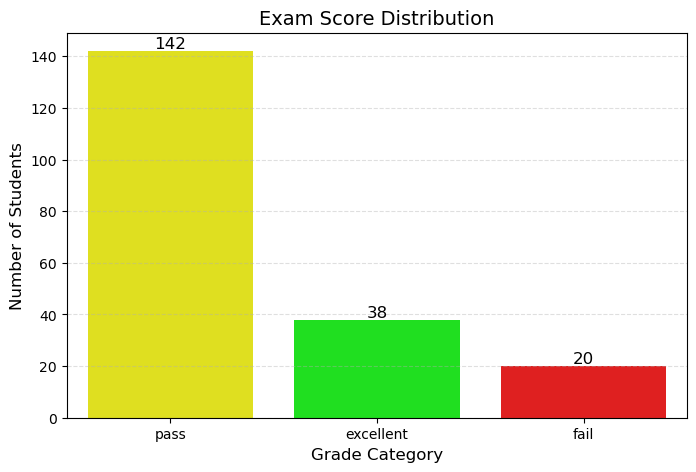

,Category,Count,Percentage (%)
0,pass,142,71.0
1,excellent,38,19.0
2,fail,20,10.0


In [5]:
# Create a summary table
table = (
    data_disc["exam_score"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

# Calculate percentages
table_pct = (
    data_disc["exam_score"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Category")
    .reset_index(name="Percentage (%)")
)

# Merge for a complete view
full_table = table.merge(table_pct, on="Category")

# Plotting
plt.figure(figsize=(8,5))
sns.barplot(
    data=full_table,
    x="Category",
    y="Count",
    palette=["#ffff00", "#00ff00", "#ff0000"]
)

plt.title("Exam Score Distribution", fontsize=14)
plt.xlabel("Grade Category", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add text labels on bars
for i, row in full_table.iterrows():
    plt.text(i, row["Count"] + 1, str(row["Count"]), ha='center', fontsize=12)

plt.show()

display(full_table)

### 5. Expert-Driven Network Structure

We manually define a network structure based on domain knowledge and logical causality.

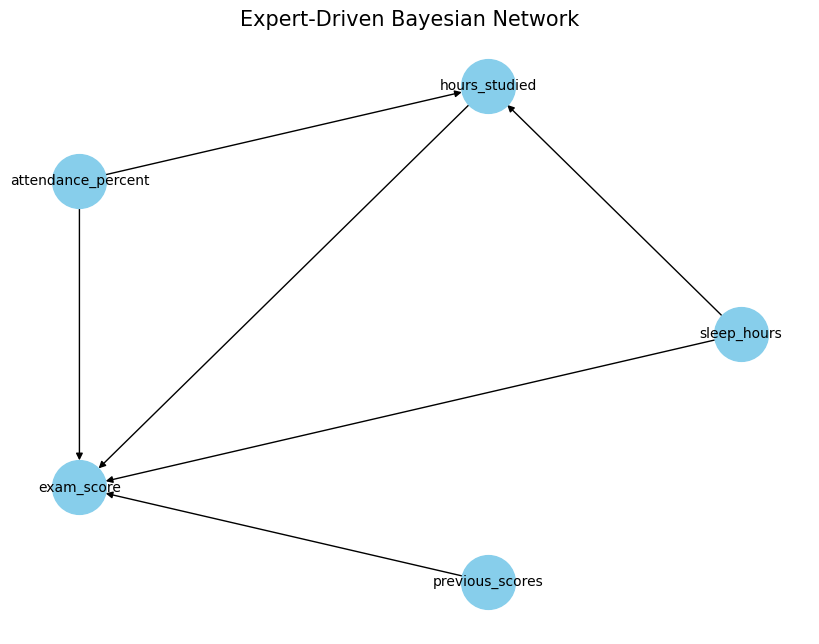

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}


In [6]:
# Define structure manually
model_ed = DiscreteBayesianNetwork([
    ('sleep_hours', 'hours_studied'),
    ('attendance_percent', 'hours_studied'),
    ('hours_studied', 'exam_score'),
    ('attendance_percent', 'exam_score'),
    ('previous_scores', 'exam_score'),
    ('sleep_hours', 'exam_score')
])

# Visualization function
def draw_graph(model, title):
    plt.figure(figsize=(8,6))
    pos = nx.kamada_kawai_layout(model)
    nx.draw(model, pos,
            with_labels=True,
            node_color="skyblue",
            node_size=1500,
            font_size=10)
    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.show()

draw_graph(model_ed, "Expert-Driven Bayesian Network")

# Fit the parameters (CPTs) to the data
model_ed.fit(data_disc, estimator=MaximumLikelihoodEstimator)

### 6. Data-Driven Structure Learning

Here, we use the Hill-Climbing algorithm with the K2 Score to mathematically determine the optimal structure that best fits the dataset, without human bias.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'N', 'sleep_hours': 'N', 'attendance_percent': 'N', 'previous_scores': 'N', 'exam_score': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'N', 'sleep_hours': 'N', 'attendance_percent': 'N', 'previous_scores': 'N', 'exam_score': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'N', 'sleep_hours': 'N', 'attendance_percent': 'N', 'previous_scores': 'N', 'exam_score': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}


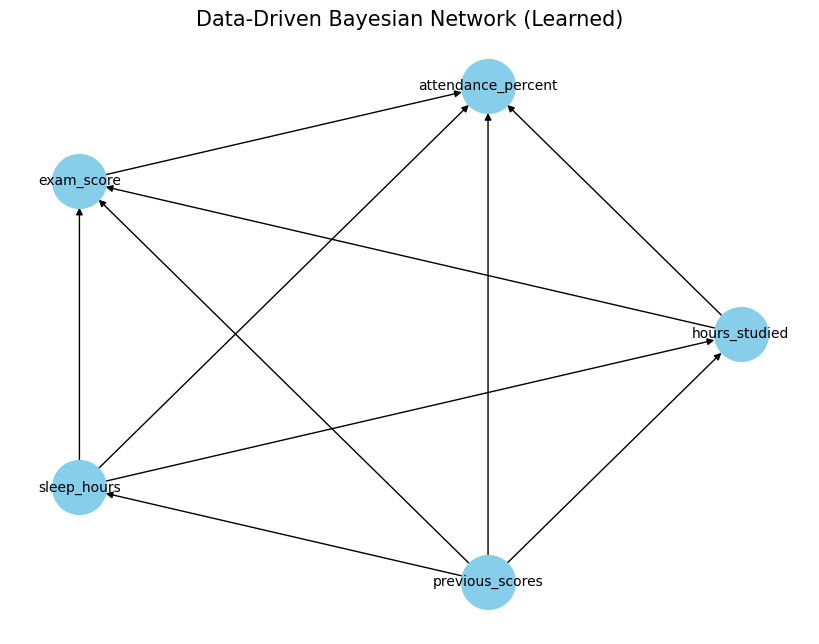

In [7]:
# Initialize Search Algorithm
hc = HillClimbSearch(data)

# Estimate best model using K2 scoring metric
best_model = hc.estimate(scoring_method="k2")

# Create model object from learned edges
model_dd = DiscreteBayesianNetwork(best_model.edges())
model_dd.fit(data_disc, estimator=MaximumLikelihoodEstimator)

# Visualize and initialize inference
draw_graph(model_dd, "Data-Driven Bayesian Network (Learned)")
infer_dd = VariableElimination(model_dd)

### 7. Model Evaluation and Comparison

We compare the two models using the Bayesian Information Criterion (BIC) score.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}


BIC Score (Expert Model): -1421.1342
BIC Score (Data-Driven):  -1528.4320

CONCLUSION: The EXPERT model fits the data better (Higher BIC).


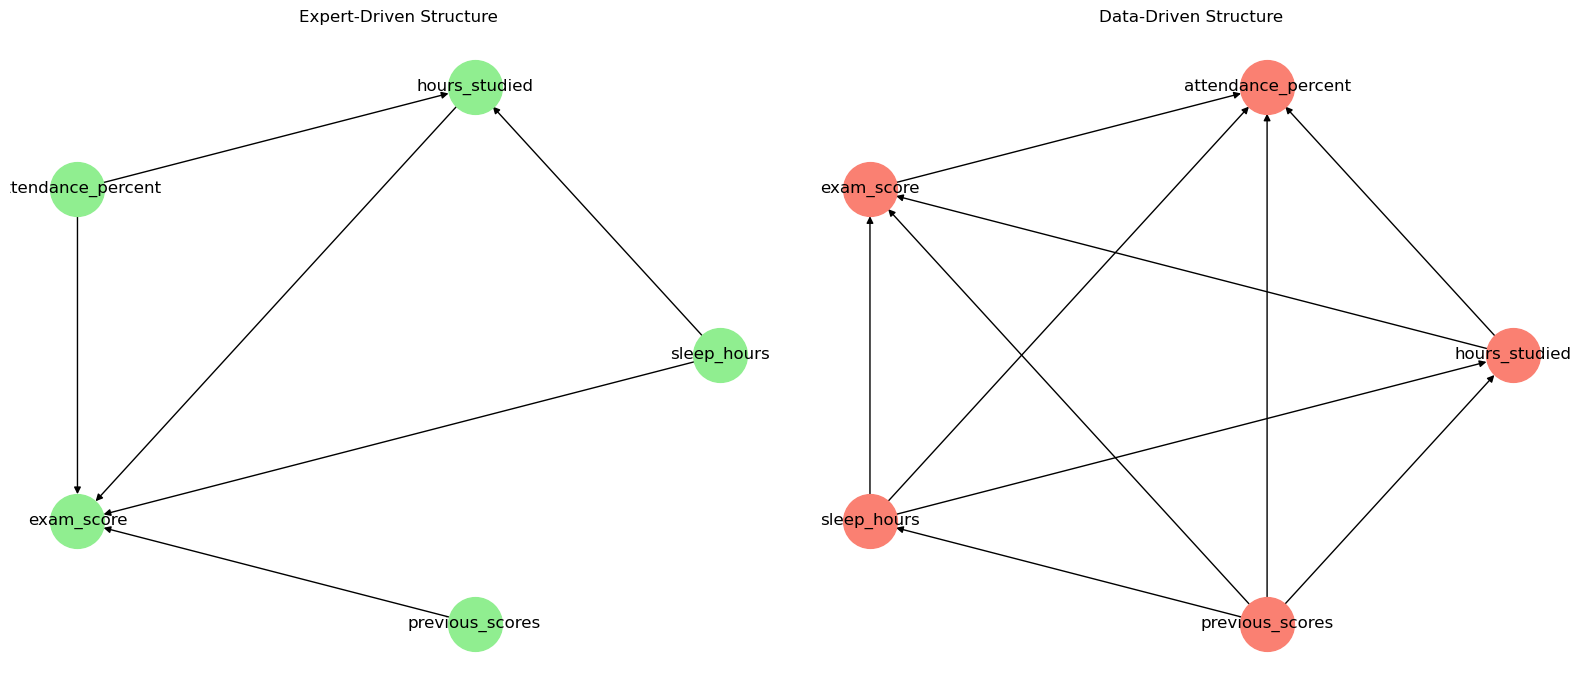

In [8]:
bic = BicScore(data_disc)

bic_expert = bic.score(model_ed)
bic_data   = bic.score(model_dd)

print(f"BIC Score (Expert Model): {bic_expert:.4f}")
print(f"BIC Score (Data-Driven):  {bic_data:.4f}\n")

if bic_data > bic_expert:
    print("CONCLUSION: The DATA-DRIVEN model fits the data better (Higher BIC).")
else:
    print("CONCLUSION: The EXPERT model fits the data better (Higher BIC).")

# Visual comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pos1 = nx.kamada_kawai_layout(model_ed)
nx.draw(model_ed, pos1, with_labels=True, node_color="lightgreen", node_size=1500, ax=axes[0])
axes[0].set_title("Expert-Driven Structure")
axes[0].axis("off")

pos2 = nx.kamada_kawai_layout(model_dd)
nx.draw(model_dd, pos2, with_labels=True, node_color="salmon", node_size=1500, ax=axes[1])
axes[1].set_title("Data-Driven Structure")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 8. Probabilistic Inference & Sensitivity Analysis

Using the Expert Model, we analyze how different states of the input variables (Low, Medium, High) change the probability of achieving an "Excellent" exam score.

In [9]:
# Initialize Inference Engine
infer = VariableElimination(model_ed)
target = "exam_score"
variables = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']

# Identify the 'Excellent' label dynamically
target_states = model_ed.get_cpds(target).state_names[target]
best_state = "excellent" 

print(f"Target State for Analysis: '{best_state}'\n")

# Iterate through variables to see their impact
for var in variables:
    results = []
    
    # Get possible states for the variable (low, medium, high)
    states = model_ed.get_cpds(var).state_names[var]

    for state in states:
        # Query the probability
        q = infer.query(variables=[target], evidence={var: state})
        
        # Extract probability of 'excellent'
        prob_val = q.values[q.state_names[target].index(best_state)]
        results.append([state, prob_val])

    df_var = pd.DataFrame(results, columns=['State', f'P({target}={best_state})'])
    
    print(f"\n - Influence of '{var}':")
    display(df_var)

Target State for Analysis: 'excellent'


 - Influence of 'hours_studied':


,State,P(exam_score=excellent)
0,high,0.401802
1,low,0.020375
2,medium,0.129279



 - Influence of 'sleep_hours':


,State,P(exam_score=excellent)
0,high,0.230969
1,low,0.116446
2,medium,0.216868



 - Influence of 'attendance_percent':


,State,P(exam_score=excellent)
0,high,0.275242
1,low,0.162153
2,medium,0.128782



 - Influence of 'previous_scores':


,State,P(exam_score=excellent)
0,high,0.354681
1,low,0.072668
2,medium,0.129573



 - Variable Importance Ranking (Sensitivity):


,Variable,Min_Prob,Max_Prob,Influence (Delta)
0,hours_studied,0.020375,0.401802,0.381427
3,previous_scores,0.072668,0.354681,0.282013
2,attendance_percent,0.128782,0.275242,0.146461
1,sleep_hours,0.116446,0.230969,0.114523


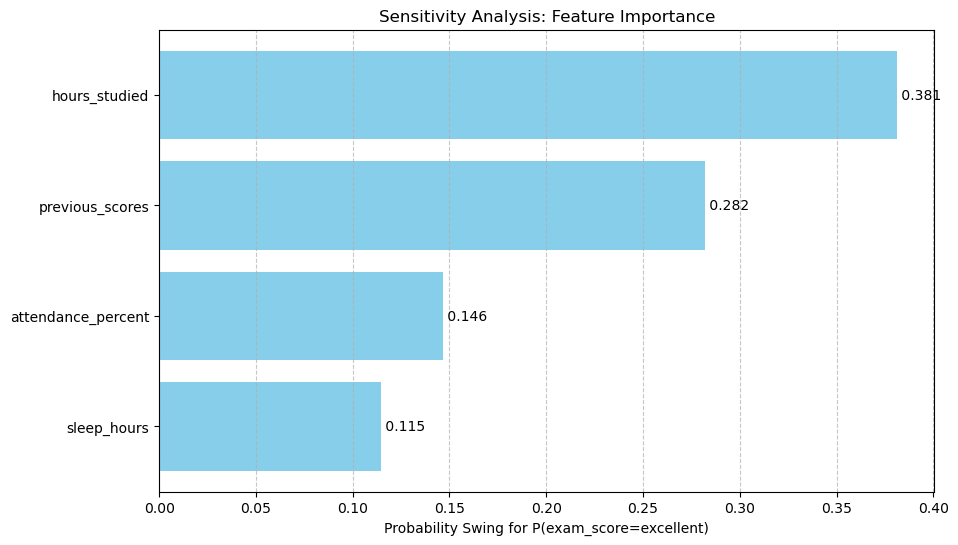

In [10]:
summary_data = []

for var in variables:
    probs = []
    states = model_ed.get_cpds(var).state_names[var]

    for state in states:
        q = infer.query(variables=[target], evidence={var: state})
        prob_val = q.values[q.state_names[target].index(best_state)]
        probs.append(prob_val)

    min_p = min(probs)
    max_p = max(probs)
    delta = max_p - min_p

    summary_data.append({
        'Variable': var,
        'Min_Prob': min_p,
        'Max_Prob': max_p,
        'Influence (Delta)': delta
    })

# Create DataFrame and Sort
df_influence = pd.DataFrame(summary_data).sort_values(
    by='Influence (Delta)', ascending=False
)

print("\n - Variable Importance Ranking (Sensitivity):")
display(df_influence)

# Plotting the Sensitivity
plt.figure(figsize=(10, 6))
df_plot = df_influence.sort_values(by='Influence (Delta)', ascending=True)

plt.barh(df_plot['Variable'], df_plot['Influence (Delta)'], color='skyblue')
plt.xlabel(f'Probability Swing for P({target}={best_state})')
plt.title('Sensitivity Analysis: Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(df_plot['Influence (Delta)']):
    plt.text(value, index, f' {value:.3f}', va='center')

plt.show()

### 9. Ablation Study: Model Optimization

Finally, we test if a simplified model (removing sleep_hours) performs better than the full complex model.

In [11]:
# 1. Full Model Structure
model_full = DiscreteBayesianNetwork([
    ('sleep_hours', 'hours_studied'),
    ('attendance_percent', 'hours_studied'),
    ('hours_studied', 'exam_score'),
    ('attendance_percent', 'exam_score'),
    ('previous_scores', 'exam_score'),
    ('sleep_hours', 'exam_score')
])

# 2. Simplified Model Structure (Without Sleep)
model_nosleep = DiscreteBayesianNetwork([
    ('attendance_percent', 'hours_studied'),
    ('hours_studied', 'exam_score'),
    ('attendance_percent', 'exam_score'),
    ('previous_scores', 'exam_score'),
])

# Estimator parameters
estimator_args = {'estimator': BayesianEstimator, 'prior_type': 'BDeu', 'equivalent_sample_size': 10}

# Train both models
model_full.fit(data_disc, **estimator_args)
model_nosleep.fit(data_disc, **estimator_args)

print("\nTraining complete.")

# Calculate Scores
bic = BicScore(data_disc)
k2 = K2(data_disc)

bic_full = bic.score(model_full)
k2_full  = k2.score(model_full)

bic_nosleep = bic.score(model_nosleep)
k2_nosleep  = k2.score(model_nosleep)

# Comparison Table
df_compare = pd.DataFrame({
    'Model': ['Full Model (with sleep)', 'Simplified (No sleep)'],
    'BIC': [bic_full, bic_nosleep],
    'K2': [k2_full, k2_nosleep]
}).set_index('Model')

print("\n - Model Comparison Results:")
display(df_compare)

# Final Conclusion Logic
best_model_name = df_compare['BIC'].astype(float).idxmax()
best_bic_val = df_compare['BIC'].max()

print(f"\nBest Model by BIC: '{best_model_name}' (Score: {best_bic_val:.2f})")

if best_model_name == 'Full Model (with sleep)':
    print("\nCONCLUSION: 'sleep_hours' adds significant value. Despite the added complexity, the model explains the data better with it included.")
else:
    print("\nCONCLUSION: The simplified model is preferable. 'sleep_hours' does not provide enough information gain to justify the added network complexity.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours_studied': 'C', 'sleep_hours': 'C', 'attendance_percent': 'C', 'previous_scores': 'C', 'exam_score': 'C'}



Training complete.

 - Model Comparison Results:


,BIC,K2
Model,,
Full Model (with sleep),-1421.134194,-1083.679666
Simplified (No sleep),-907.936985,-833.665355



Best Model by BIC: 'Simplified (No sleep)' (Score: -907.94)

CONCLUSION: The simplified model is preferable. 'sleep_hours' does not provide enough information gain to justify the added network complexity.
